# Importing necessary libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import warnings
warnings.simplefilter(action='ignore')

# Loading dataset

In [2]:
df=pd.read_csv("insurance.csv")
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
df.shape                                            # Checking for shape of data

(1338, 7)

In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Data Cleaning

## Checking for missing values

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Checking for outliers using boxplot

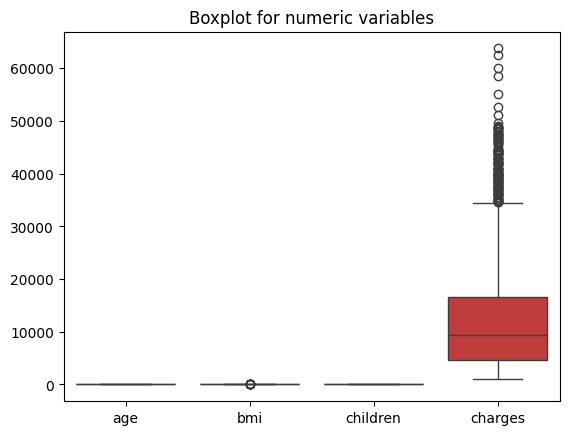

In [6]:
sns.boxplot(df)
plt.title('Boxplot for numeric variables')
plt.show()

## Removing outliers

In [7]:
columns_to_clean = ['bmi', 'charges']
df_cleaned = df.copy()

for column in columns_to_clean:
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out the outliers
    df_cleaned = df_cleaned[(df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")

Original DataFrame shape: (1338, 7)
Cleaned DataFrame shape: (1191, 7)


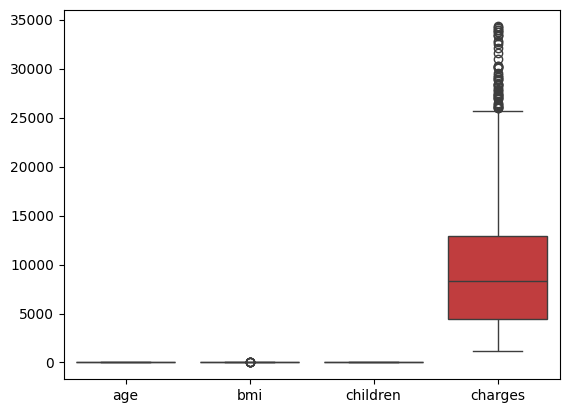

In [8]:
sns.boxplot(df_cleaned)
plt.show()

# Exploratory data analysis

## Histogram of insurance charges

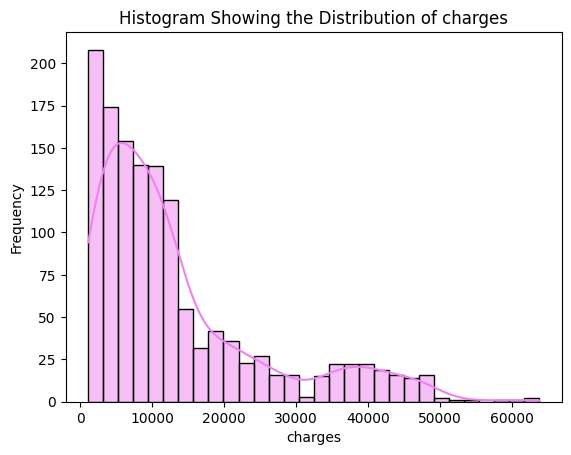

In [9]:
sns.histplot(df, x='charges', bins=30, kde=True, color="violet")
plt.title("Histogram Showing the Distribution of charges")
plt.xlabel("charges")
plt.ylabel("Frequency")
plt.show()

## Boxplot of charges by smokerstatus

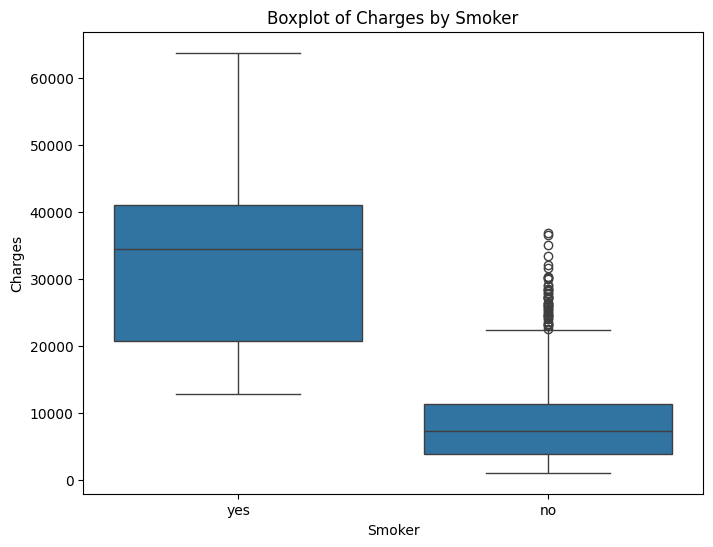

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Boxplot of Charges by Smoker')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

## Scatterplot of bmi vs charges

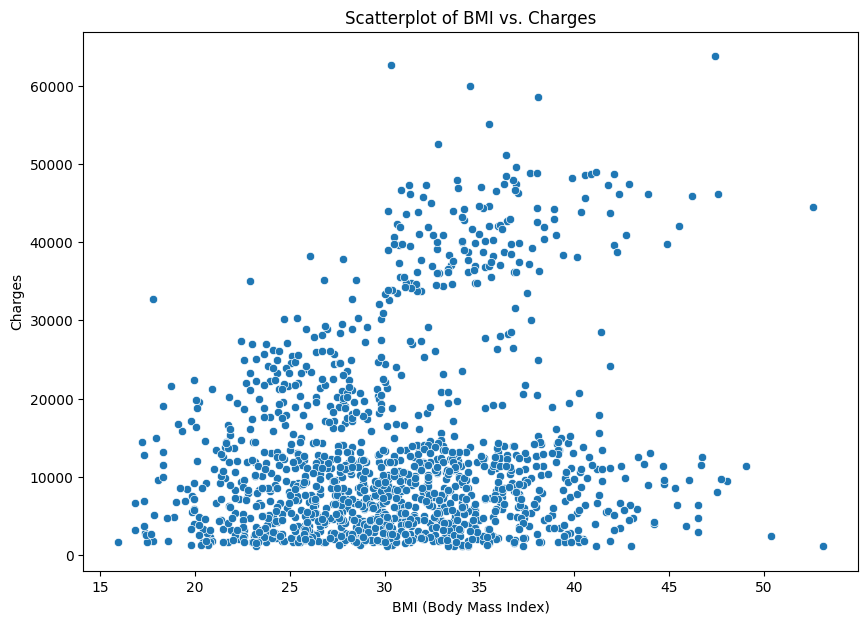

In [11]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('Scatterplot of BMI vs. Charges')
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Charges')
plt.show()

## Regression plot of bmi vs charges

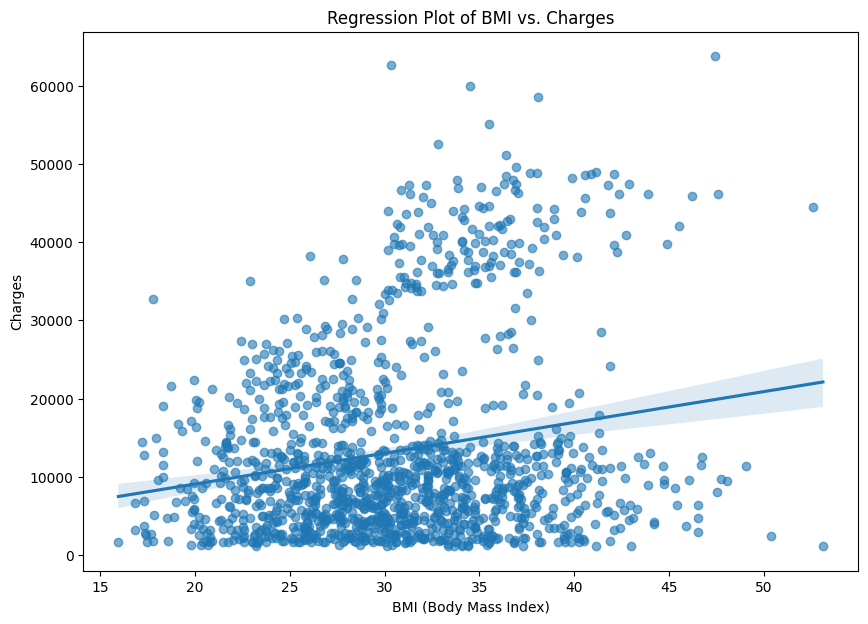

In [12]:
plt.figure(figsize=(10, 7))
sns.regplot(x='bmi', y='charges', data=df, scatter_kws={'alpha':0.6})
plt.title('Regression Plot of BMI vs. Charges')
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Charges')
plt.show()

## Barplot of average charges by region

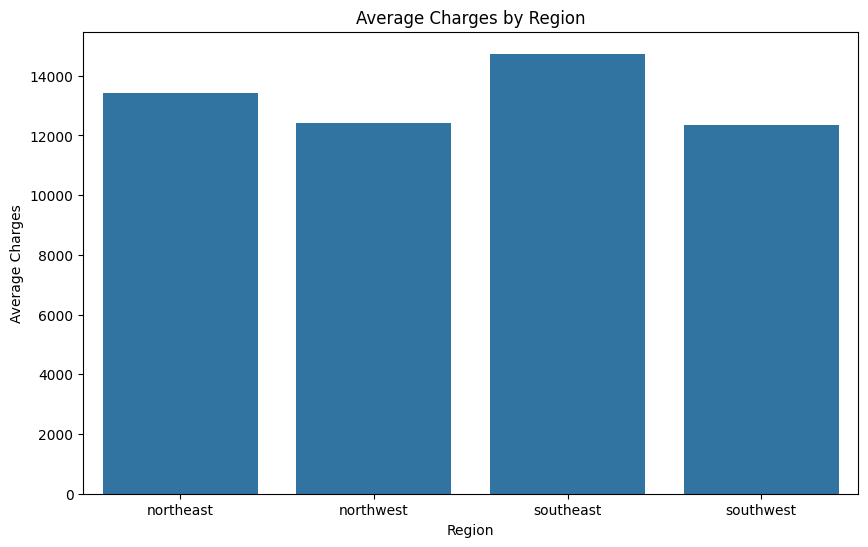

In [13]:
mean_charges_by_region = df.groupby('region')['charges'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='region', y='charges', data=mean_charges_by_region)
plt.title('Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.show()

## Correlation heatmap

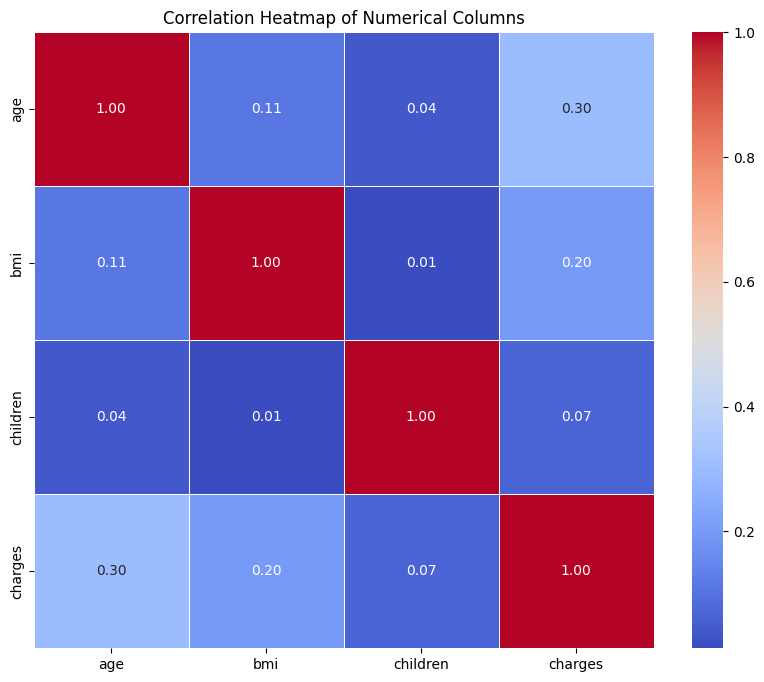

In [14]:
numerical_df = df.select_dtypes(include=['number'])
corr_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

Age,bmi and children show weak positive correlation with insurance charges

# Categorical encoding

In [23]:
pd.get_dummies(df[['sex', 'region', 'smoker']]).head().astype(int)

,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,1,0,0,0,0,1,0,1
1,0,1,0,0,1,0,1,0
2,0,1,0,0,1,0,1,0
3,0,1,0,1,0,0,1,0
4,0,1,0,1,0,0,1,0


# Simple linear regression

In [16]:
X=sm.add_constant(df['bmi'])
y=df['charges']
model=sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.71
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           2.46e-13
Time:                        14:25:27   Log-Likelihood:                -14451.
No. Observations:                1338   AIC:                         2.891e+04
Df Residuals:                    1336   BIC:                         2.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1192.9372   1664.802      0.717      0.4

The constant is 1192.9372 thus when the bmi is zero the insurance charges are 1192.9372 
The coefficient of bmi is 393.8730 thus each unit increase in bmi corresponds with a 393 units increase in charges
The p value of the constant is 0.474 thus not statistically significant at convectional level
The p value of bmi is 0 thus is statistically significant
R squared and adjusted R squared values are 0.039 thus 3.9% of the variation in charge is explained by bmi


In [17]:
X=df[['bmi']] # Select only the feature column
y=df['charges']

model=LinearRegression()
model.fit(X,y)

print('Intercept',model.intercept_)
print('Slope(bmi df):',model.coef_[0])
y_pred=model.predict(X)
print('predicted values:',y_pred)

Intercept 1192.9372089611497
Slope(bmi df): 393.87303079739524
predicted values: [12181.99476821 14494.02945899 14190.74722528 ... 15707.15839385
 11354.86140353 12642.82621424]


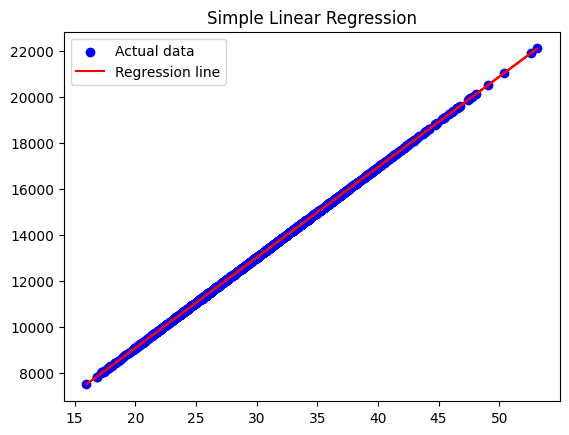

In [18]:
plt.scatter(X, y_pred, color='blue', label='Actual data')
plt.plot(X, y_pred, color='red', label='Regression line')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

In [24]:
# Create dummy variables for categorical columns and convert them to integers
df_dummies = pd.get_dummies(df[['sex', 'region', 'smoker']]).astype(int)

# Prepare the feature matrix X by combining numerical features and dummy variables
x_numerical = df[['age', 'children', 'bmi']]
x = pd.concat([x_numerical, df_dummies], axis=1)

# Prepare the target variable y
y = df['charges']

# Add a constant to the independent variable for the OLS model
x = sm.add_constant(x)

# Fit the OLS model
model = sm.OLS(y,x).fit()

# Get predictions
predictions = model.predict(x)

# Print the model summary
print_model = model.summary()
print(print_model)

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:51:51   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             -296.4168    430.507  

The variables age,bmi and smoker status influence charges the most.
Smoking significantly influences the charges.
Multiple linear regression is better than simple linear regression since 75% of variation in the charges is represented by the model compared to 3.9 in simple linear regression
  
